<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


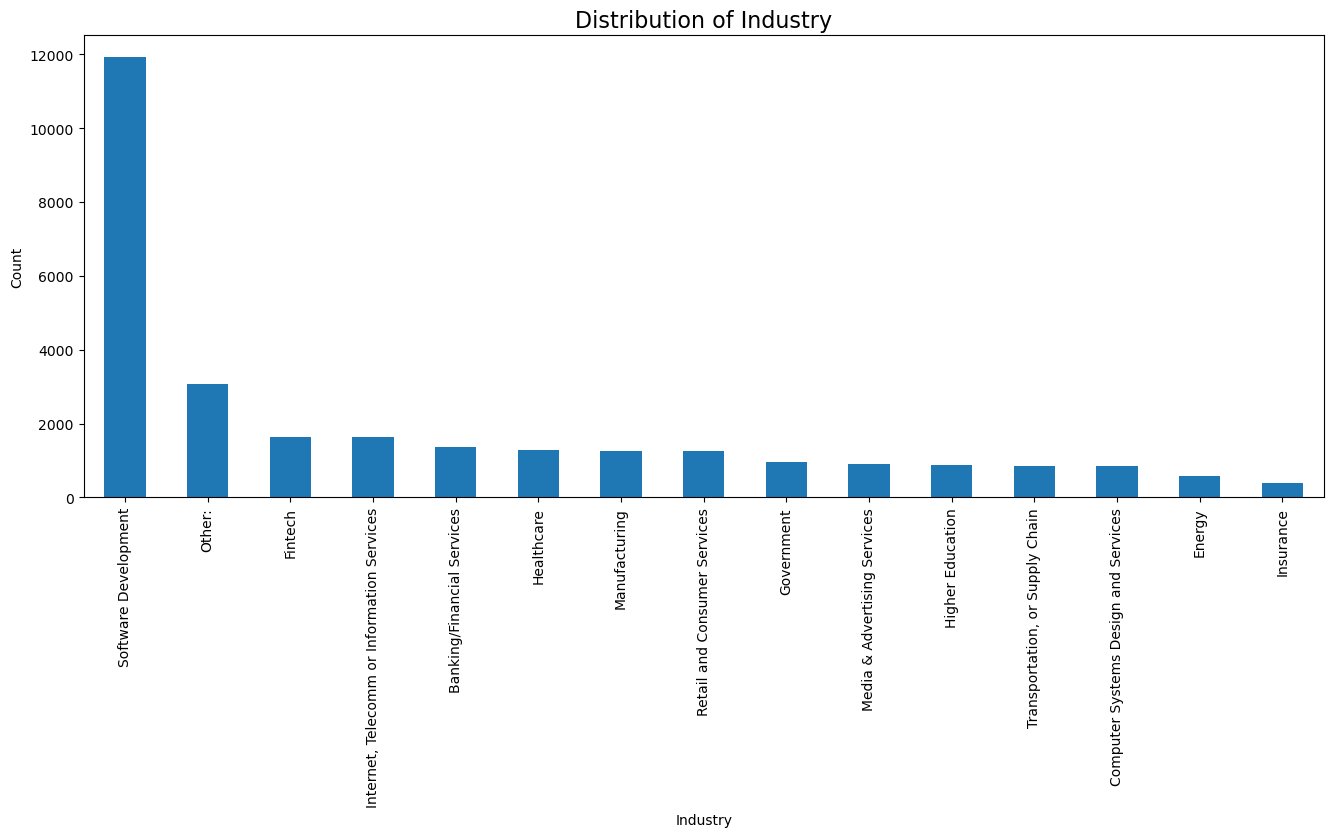

In [16]:
##Write your code here
count=df['Industry'].value_counts().sort_values(ascending=False)
count.plot(kind='bar', figsize=(16,6))
plt.title('Distribution of Industry', fontsize=16)
plt.xlabel('Industry')
plt.ylabel('Count')
plt.show()

Most of the respondents, about 12000, are from Software Development industry. The dataset is biased towards software professionals.

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [42]:
##Write your code here
mean= round(df['ConvertedCompYearly'].mean(),2)
median= round(df['ConvertedCompYearly'].median(),2)
std= round(df['ConvertedCompYearly'].std(),2)
print('Mean for ConvertedCompYearly:', mean)
print('Median for ConvertedCompYearly:', median)
print('Standard Deviation for ConvertedCompYearly:', std)
print('Compensation values exceeding defined threshold:', round((mean + 3*std),2))

Mean for ConvertedCompYearly: 86155.29
Median for ConvertedCompYearly: 65000.0
Standard Deviation for ConvertedCompYearly: 186756.97
Compensation values exceeding defined threshold: 646426.2


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


In [49]:
##Write your code here
Q1= df['ConvertedCompYearly'].quantile(0.25)
Q3= df['ConvertedCompYearly'].quantile(0.75)
IQR= Q3-Q1
Upper= Q3 + 1.5*IQR
Lower= Q1 - 1.5*IQR
outliers= df[(df['ConvertedCompYearly'] < Lower) | (df['ConvertedCompYearly'] > Upper)]
print('IQR of ConvertedCompYearly:', IQR)
print('Upper bounds of ConvertedCompYearly:', Upper)
print('Lower bounds of ConvertedCompYearly:', Lower)
print('Number of outliers:', len(outliers))

IQR of ConvertedCompYearly: 75259.5
Upper bounds of ConvertedCompYearly: 220860.75
Lower bounds of ConvertedCompYearly: -80177.25
Number of outliers: 978


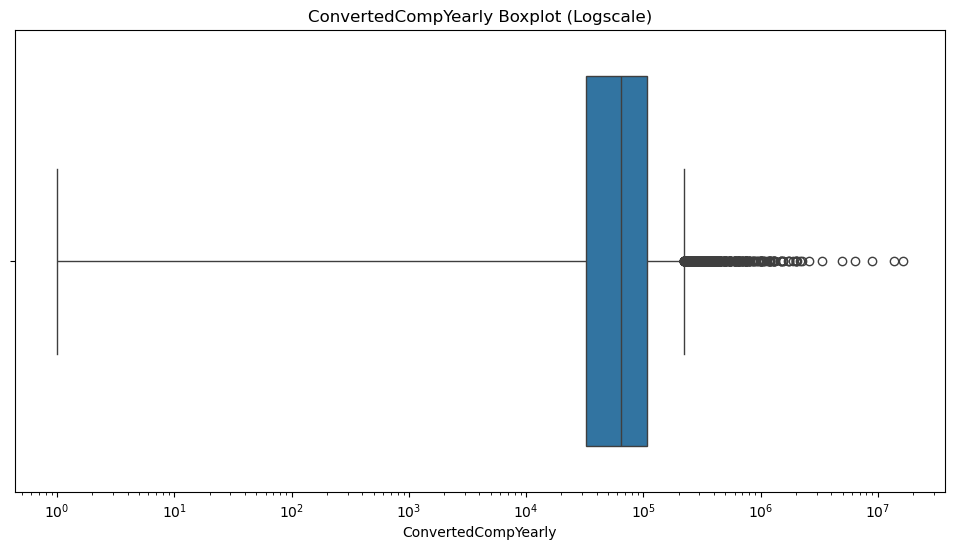

In [52]:
#Visualization
plt.figure(figsize=(12,6))
sns.boxplot(x=df['ConvertedCompYearly'])
plt.title('ConvertedCompYearly Boxplot (Logscale)')
plt.xscale('log')

plt.show()

The boxplot reveals that the distribution of yearly compensation is highly right-skewed. Most respondents earn within a relatively moderate salary range, while a small number report extremely high compensation values. These high values appear as outliers and significantly extend the upper range of the distribution.

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [53]:
##Write your code here
df_no_outliers= df[(df['ConvertedCompYearly'] >= Lower) & (df['ConvertedCompYearly'] <= Upper)]
print('Before remove outlier dataset size:', df.shape)
print('After remove outlier dataset size:', df_no_outliers.shape)

Before remove outlier dataset size: (65437, 114)
After remove outlier dataset size: (22457, 114)


<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [72]:
df['YearsCodePro'].unique()

array([nan, '17', '27', '7', '11', '25', '12', '10', '3', 0.5, '18', '37',
       '15', '20', '6', '2', '16', '8', '14', '4', '45', '1', '24', '29',
       '5', '30', '26', '9', '33', '13', '35', '23', '22', '31', '19',
       '21', '28', '34', '32', '40', '50', '39', '44', '42', '41', '36',
       '38', 51, '43', '47', '48', '46', '49'], dtype=object)

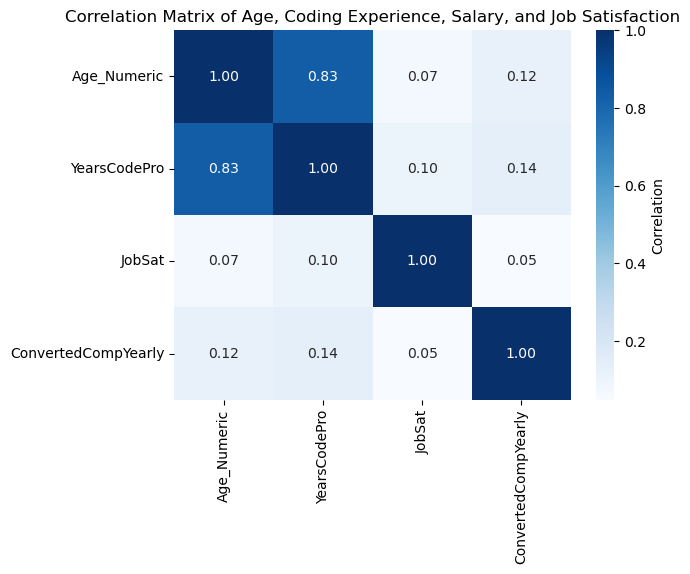

In [78]:
##Write your code here
import numpy as np

#Use midpoint of age
age_map= {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 66,
    'Prefer not to say': np.nan
}
#Do mapping
df['Age_Numeric']= df['Age'].map(age_map)
#Drop NAN from age_numeric
df= df.dropna(subset='Age_Numeric')
#Replace string values in YearsCodePro
df['YearsCodePro']= df['YearsCodePro'].replace({'Less than 1 year': 0.5, 'More than 50 years': 51})
#list numeric columns
num_cols= ['Age_Numeric','YearsCodePro', 'JobSat', 'ConvertedCompYearly']

corr_matrix= df[num_cols].corr()
#Visualization
sns.heatmap(corr_matrix, cmap='Blues', fmt='.2f', annot=True, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix of Age, Coding Experience, Salary, and Job Satisfaction')

plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
